# The Rubiks Cube Scrambling Markov Chain

Fix $n \in \lbrace 2, 3 \rbrace.$ Recall the $\textbf{$n$-dimensional Rubik's Cube}$ is a cube such that each of its $6$ square faces is partitioned into $n^2$ smaller colored squares, known as $\textbf{stickers}.$ Each sticker takes one color from a set of $6$ distinct colors. We refer to any state of the cube with its $n^2$ colored stickers as a $\textbf{(colored) cube configuration}.$ 

Examples of cube configurations are shown below for $n=2$ and $3,$ respectively.
<table><tr>
    
<td>  <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%202x2x2%201.gif" alt="Drawing" style="width: 200px;"/> <figcaption> An Arbitrary 2D Rubik's Cube Configuration </figcaption> 
<td>  <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%203x3x3%201.gif" alt="Drawing" style="width: 200px;"/> <figcaption> An Arbitrary 3D Rubik's Cube Configuration </figcaption>  </td>
</tr></table>

We refer to a $\textbf{solved configuration}$ as a configuration such that each square face has its $n^2$ stickers that are of the same color.

Examples of solved cube configurations are shown below for $n=2$ and $3,$ respectively.
<table><tr>
<td> <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%202x2x2%202.gif" alt="Drawing" style="width: 200px;"/> <figcaption> A Solved 2D Rubik's Cube Configuration </figcaption> 
<td> <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%203x3x3%202.gif" alt="Drawing" style="width: 200px;"/> <figcaption> A Solved 3D Rubik's Cube Configuration </figcaption> </td>
</tr></table>

Recall we can transition between any two cube configurations via a sequence of successive face rotations. A $\textbf{face rotation (scramble)}$ is either a $90$ degrees clockwise (or counterclockwise) rotation of a chosen face.

## Problem Statements

Fix the dimension $n \in \lbrace 2,3 \rbrace$ and define $\mathcal{G}_n$ to be the set of all possible cube configurations for that dimension. Given an arbitrary cube configuration $c \in \mathcal{G}_n,$ the standard puzzle is to $\textbf{solve (unscramble)}$ it, which means to find a sequence of face rotations such that when such rotations are applied in succession, we obtain a solved configuration. 

For each $c \in \mathcal{G}_n,$ let $m_c$ be the $\textit{minimal}$ number of face rotations needed to obtain a solved configuration from $c.$ Define $\textbf{God's number}$ to be the number $$M_n=\max_{c \in \mathcal{G}_n} m_c.$$ In words, $M_n$ is the maximum number of moves needed to efficiently unscramble the cube.

We pose the following question:

* What is the value of $M_n$ ?

Next, begin with a solved configuration of the cube, and consider the reverse process of unscrambling, namely scrambling. Let $t$ be a fixed number of face rotations made (which we refer to as $\textbf{scrambles}$). We pose the following questions:

* Given each configuration $c \in \mathcal{G}_n,$ what is the probability of obtaining $c$ in exactly $t$ scrambles ? 
* As $t$ gets large, is it possible to obtain most, if not all, configurations in $\mathcal{G}_n$ with equal probability ? 

In order to answer all these questions, we will use tools from basic Group Theory and Markov Chain theory.

In [1]:
from CubeConfiguration import *
from CubePermutation import *
from MarkovGraph import *
from MarkovChainCalculations import *
import matplotlib.pyplot as plt

## Orienting the Rubiks Cube

Fix a dimension $n \in \lbrace 2,3 \rbrace.$ We discuss how to orient the faces of Rubiks cube. 


The diagram below identifies the front (F), left (L), up (U), back (B), right (R), down (D) faces of a cube configuration.

<!-- <table><tr>
<td> <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%20znaceni%20tahu%201.png" alt="Drawing" with="100px"/> <figcaption>Configuration with Identified Faces and their Clockwise Orientations </figcaption> </td>
</tr></table>
 -->

<table><tr>
<td> <img src="https://images.saymedia-content.com/.image/c_limit%2Ccs_srgb%2Cq_auto:eco%2Cw_1200/MTc0MjYyNzAyNzY2NTY1MjQ0/rubik-cube-algorithms.webp" alt="Drawing" width="500px"/> <figcaption>Configuration with Identified Faces and Orientations </figcaption> </td>
</tr></table>


Now, we specify the orientation of a face as follows: if the face were to appear directly in front of the screen, 
* For F: The corresponding red arrow in the above diagram appears on the top of the face and is facing right on the screen.
* For L: The corresponding red arrow in the above diagram appears on the right of the face and is facing down on the screen.
* For U: The corresponding red arrow in the above diagram appears on the bottom of the face and is facing left on the screen.
* For B: The corresponding red arrow in the above diagram appears on the top of the face and is facing right on the screen.
* For R: The corresponding red arrow in the above diagram appears on the left of the face and is facing up on the screen.
* For D: The corresponding red arrow in the above diagram appears on top of the face and is facing right on the screen.


A $\textbf{face rotation (scramble)}$ is a $90$ degree clockwise/counterclockwise rotation of a cube's face, where clockwise/counterclockwise directions are relative to face's specified orientation from above. 

## Cube Sticker Enumeration Scheme 

Fix any solved configuration. We enumerate all its $6n^2$ stickers from the set $\lbrace 0, \ \dots \ , 6n^2-1 \rbrace$ in the following order of faces: F, L, U, B, R, and D, in which we view each face according to the above orientation procedure. We enumerate the stickers of each face in row-wise fashion.

For example, in the case $n=2,$ if we identify each face of $\iota$ as a $2 \times 2$ matrix with stickers as entries, the enumeration procedure above will yield: 
$$F= \begin{bmatrix} 0 & 1 \\ 2 & 3 \end{bmatrix},  \ L= \begin{bmatrix} 4 & 5 \\ 6 & 7 \end{bmatrix},  \ U= \begin{bmatrix} 8 & 9 \\ 10 & 11 \end{bmatrix}, \ B = \begin{bmatrix} 12 & 13 \\ 14 & 15 \end{bmatrix}, \ R = \begin{bmatrix} 16 & 17 \\ 18 & 19 \end{bmatrix}, \ D= \begin{bmatrix} 20 & 21 \\ 22 & 23 \end{bmatrix}.$$

## Obtaining New Cube Configurations via Face Rotations

In the code cell below, we output the above solved configuration with enumerated stickers as a dictionary. The dictionary contains the face names as keys and corresponding $n \times n$ face matrices as values. We also output $3$ different sample configurations corresponding to $3$ different sample clockwise face rotations applied to our solved configuration. One can verify these results by inspection in real life. 

In [2]:
n=2
solved_cube_configuration_dict=CubeConfiguration(n).configuration_dict

print("Original Solved Cube Configuration : {}".format(str(solved_cube_configuration_dict)))
print(" ")

for face_name in face_names[:3]:
    print("Configuration Resulting From Rotating the {} Face Clockwise : {}".format(face_name,
                                                                                str(CubeConfiguration(n).rotate_face(face_name))))
    print(" ")

Original Solved Cube Configuration : {'Front': array([[0, 1],
       [2, 3]]), 'Left': array([[4, 5],
       [6, 7]]), 'Up': array([[ 8,  9],
       [10, 11]]), 'Back': array([[12, 13],
       [14, 15]]), 'Right': array([[16, 17],
       [18, 19]]), 'Down': array([[20, 21],
       [22, 23]])}
 
Configuration Resulting From Rotating the Front Face Clockwise : {'Front': array([[2, 0],
       [3, 1]]), 'Left': array([[ 4, 20],
       [ 6, 21]]), 'Up': array([[8, 9],
       [7, 5]]), 'Back': array([[12, 13],
       [14, 15]]), 'Right': array([[10, 17],
       [11, 19]]), 'Down': array([[18, 16],
       [22, 23]])}
 
Configuration Resulting From Rotating the Left Face Clockwise : {'Front': array([[ 8,  1],
       [10,  3]]), 'Left': array([[6, 4],
       [7, 5]]), 'Up': array([[15,  9],
       [13, 11]]), 'Back': array([[12, 22],
       [14, 20]]), 'Right': array([[16, 17],
       [18, 19]]), 'Down': array([[ 0, 21],
       [ 2, 23]])}
 
Configuration Resulting From Rotating the Up Face Clo

## Permutations 

For each $m \in \mathbb{N},$ let $S_m$ is the set of all bijections from the set $\lbrace 0, \ \dots \ , m-1 \rbrace$ to itself. Recall this is a group under function composition. Elements of $S_m$ are known as $\textbf{permutations}.$

We say a permutation $\tau \in S_m$ is a $\textbf{cyclic permutation}$ if there exist distinct $i_1, \ \dots \ , i_k \in \lbrace 0, \ \dots \ , m-1 \rbrace$  such that $\tau(i_j)=\tau_{i_{j+1}}$ for all $1 \le j \le k-1$ and $\tau(i_k)=i_1.$ In this case, we adopt the conventional $\textbf{cyclic notation},$ in which we write $$\tau=(i_1 \ \dots \  i_k).$$ 

Let $\tau=(i_1 \ \dots \  i_k)$ and $\kappa=(j_1 \ \dots \  j_m)$ be cyclic permutations in $S_m.$ We say $\tau$ and $\kappa$ are $\textbf{disjoint}$ if the numbers $i_1, \ \dots \ , i_k,  j_1, \ \dots \ , j_m$ are all distinct. It is a well-known theorem that every $\sigma \in S_m$ can be written as a composition of pairwise disjoint cyclic permutations in $S_m.$

## Identifying Cube Configurations with Permutations

We identify our chosen solved configuration from above with the identity permutation $\textbf{Id}_{6n^2} \in S_{6n^2}.$ Note that any face rotation is a permutation of enumerated stickers from $S_{6n^2}.$ We let $\mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D} \in S_{6n^2}$ be the permutations representing the clockwise face rotations (applied to our chosen solved configuration) of the faces F, L, U, B, R, D, respectively. Define $\mathcal{H}_n= \langle \mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D} \rangle$ in $S_{6n^2},$ which is the subgroup generated by the clockwise face rotations. Explicitly,
$$\mathcal{H}_n= \left \lbrace \mathbf{M}_1 \circ \ \dots \ \circ \mathbf{M}_k: k \in \mathbb{N}, \  \mathbf{M}_i \in \left \lbrace \mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D} \right \rbrace \right \rbrace.$$

$\textbf{Theorem}:$ There is a bijective correspondence between $\mathcal{G}_n$ and $\mathcal{H}_n.$ In other words, each cube configuration can be uniquely identified with a composition of clockwise face rotation permutations.  

In the code cell below, we output the permutations $\mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D}$ in cyclic notation.

$\textbf{Note}:$ When $n=2,$ one can confirm by inspection that for any cube configuration, rotating the front face thrice yields the same configuration as rotating the back face (up to vantage point). Hence, in the case $n=2,$ we can replace $\mathbf{B}$ with $\mathbf{F}^3.$ Similarly, we can replace $\mathbf{D}$ with $\mathbf{U}^3$ and $\mathbf{R}$ with $\mathbf{L}^3.$ However, when $n=3,$ such replacements cannot be made.

In [3]:
n=2
clockwise_basic_permutations = CubePermutation(n).clockwise_basic_permutations
print(clockwise_basic_permutations)

(Permutation(23)(0, 2, 3, 1)(5, 20, 18, 11)(7, 21, 16, 10), Permutation(23)(0, 8, 15, 20)(2, 10, 13, 22)(4, 6, 7, 5), Permutation(23)(0, 16, 12, 4)(1, 17, 13, 5)(8, 10, 11, 9), Permutation(23)(0, 1, 3, 2)(5, 11, 18, 20)(7, 10, 16, 21), Permutation(23)(0, 20, 15, 8)(2, 22, 13, 10)(4, 5, 7, 6), Permutation(23)(0, 4, 12, 16)(1, 5, 13, 17)(8, 9, 11, 10))


## Determining God's Number via A Devil's Algorithm. 

We are ready to answer the first question we posed, which is to determine God's number $M_n$ for the $n$-dimensional Rubiks Cube. Recall God's number is the maximum number of moves needed to efficiently unscramble the cube.

In order to do this, we iteratively construct the entire subgroup $\mathcal{H}_n= \langle \mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D} \rangle.$ We do this as follows.

* Define $\mathcal{H}_{1,n} = \lbrace \mathbf{Id}_{6n^2} \rbrace.$ 
* For each $k>1,$ we define $$\mathcal{H}_{k,n} = \mathcal{H}_{k-1,n} \cup  \left \lbrace \mathbf{M} \circ \sigma: \ \sigma \in \mathcal{H}_{k,n}, \  \mathbf{M} \in \left \lbrace \mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D} \right \rbrace \right \rbrace.$$
* We terminate the algorithm once we find a $k \in \mathbb{N}$ such that $\mathcal{H}_{k,n}=\mathcal{H}_{k-1,n}.$

$\textbf{Theorem}:$ The above algorithm terminates for some $k \in \mathbb{N}.$ For such a $k,$ we have $\mathcal{H}_{k,n}=\mathcal{H}_n.$ Furthermore, the smallest such $k$ is equal to $M_n.$
 
We verified that $M_2=14$ and $|\mathcal{H}_2|=3671460.$ It was proven by Google that for $n=3,$ $M_3 = 20.$ But we do not have enough computing power to verify this.

We implement this algorithm in the code cell below.

In [4]:
# n=2
# MG=MarkovGraph(n)
# for k in range(12):
    # print("ITERATION {}".format(k+2))
    # MG.update_current_permutations_dict()
    # MG.update_transition_matrix_nonzero_entry_row_column_indices_dict()
    # MG.update_transition_matrix_COO_format()

## Markov Chain

Let $\lbrace S_t \rbrace_{t \ge 0}$ be a collection of random variables defined on a common state space $\mathcal{S}.$ We say $\lbrace S_t \rbrace_{t \ge 0}$ is a $\textbf{Markov Chain}$ if for all $t \ge 0,$ and all $s_0, \ \dots \ , s_{t+1} \in \mathcal{S},$ we have that 

$$\text{Pr}\left(S_{t+1} = s_{t+1} \ | \ S_{t} = s_t \right) = \text{Pr}\left(S_{t+1} = s_{t+1} \ | \ S_{t} = s_t \cap  S_{t-1}=s_{t-1}, \ \dots \ \cap S_0=s_0  \right),$$ where $\text{Pr}(B \ | \ A)$ denotes the conditional probability of event $B$ given event $A$ occurred.

## Constructing The Rubiks Cube Scrambling Markov Chain

Let $N= \#  \ \mathcal{G}_n.$ Enumerate $\mathcal{G}_n=\lbrace g_0, \ \dots \ , g_{N-1} \rbrace,$ and identify each $g_i$ with its unique composition of face rotation permutations from $\mathcal{H}_n.$ 

We define $G_0$ to be the constant random variable $\textbf{Id}_{6n^2} \rbrace$ and $G_t$ to be the random variable representing the permutation obtained after $t$ scrambles for each $t \in \mathbb{N}.$ Each random variable is defined on the common state space $\mathcal{G}_n.$ We call the collection of random variables $\lbrace G_t \rbrace_{t \ge 0}$ the $\textbf{scrambling chain}.$

$\textbf{Theorem}:$ The Scrambling Chain is a Markov Chain.

This is clear because the value of $G_{t+1}$ depends only the value of $G_t.$ In particular, $\text{Pr}\left(G_{t+1} = g_{t+1} \ | \ G_{t} = g_t \right)$ is $1/6$ if $g_{t+1}$ is attainable from $g_t$ via a face rotation and $0$ otherwise.

Associated with this Markov Chain is an $N \times N$ transition matrix $P,$ whose $(i,j)$-th entry is 
$$P_{i,j}=\text{Pr}\left(G_{t+1}= g_j \ | \ G_{t}=g_i \right)$$ for all $i,j \in \lbrace 0, \ \dots  \ , N-1 \rbrace.$ One can verify that each entry of this matrix is actually defined independent of the value of $t.$

$\textbf{Theorem}:$ We have that $P$ is a symmetric matrix i.e. $P_{i,j}=P_{j,i}.$ It is also a sparse matrix with each row having exactly $6$ nonzero entries all being $1/6.$ 

In the code cell below, we load the transition matrix $P$ in $\textbf{coordinate list (COO) format},$ which is a special type of data representation encoding position of nonzero matrix entries. This format makes it suitable for future sparse matrix-vector calculations.  

In [5]:
n=2
MG=MarkovGraph(n)
transition_matrix=MG.transition_matrix
transition_matrix

LOADING SPARSE TRANSITION MATRIX ...
DONE !!!


<3674160x3674160 sparse matrix of type '<class 'numpy.float64'>'
	with 22044960 stored elements in COOrdinate format>

## Obtaining Markov Chain Distributions

For each $t \ge 0,$ we define $\pi_t$ to be the probability distribution corresponding to the random variable $G_t.$ Explicitly, for each $g \in \mathcal{G}_n,$ we have $$\pi_t(g)=\text{Pr}(G_t=g).$$

$\textbf{Theorem}:$ For each $t \ge 0$ and $i \in \lbrace 0, \ \dots \ , N-1 \rbrace,$ we have 

\begin{align*}
    \pi_{t+1}(g_i) &= \sum_{j=0}^{N-1} P_{i,j} \pi_{t}(g_j).
\end{align*}

As a matter of fact, we can recursively compute $\pi_t$ using sparse matrix-vector multiplication. For each $t \ge 0,$ denote
$$\boldsymbol{\pi}_t=(\pi_t(g_0), \ \dots \ , \pi_t(g_{N-1})) \in \mathbb{R}^N.$$ Then, our above theorem is equivalent to the statement
$$\boldsymbol{\pi}_{t+1} = P \boldsymbol{\pi}_t$$ for each $t \ge 0.$ 

We implement this formula in the code cell below and compute the first $30$ chain distributions. We plot the first few distributions as well.

$\textbf{Conjecture}:$ If $t$ is even, it seems that $\pi_t \left(\textbf{Id}_{6n^2} \right) > \pi_t(g)$ for all $g \ne \textbf{Id}_{6n^2}.$ In words, after an even number of scrambles, it seems we are most likely to recover the solved configuration we started with. Hence, after a large number of scrambles, we speculate that we cannot obtain all cube configurations with equal probability.

LOADING SPARSE TRANSITION MATRIX ...
DONE !!!


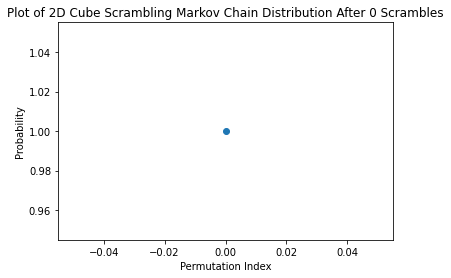

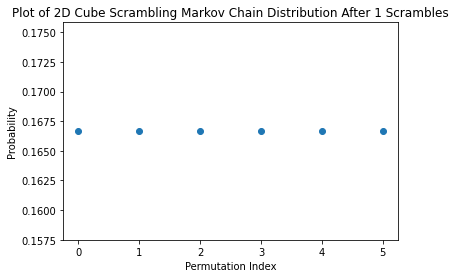

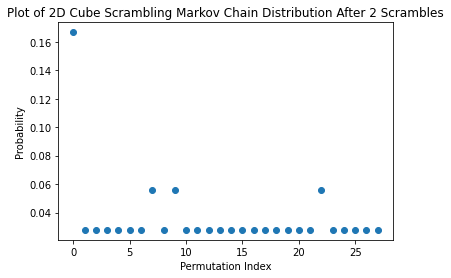

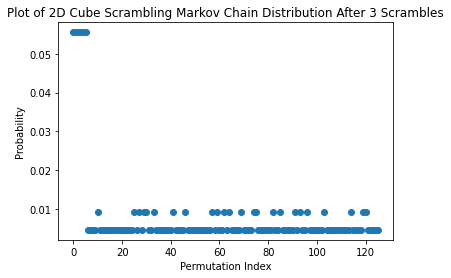

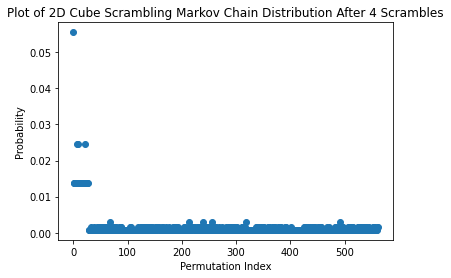

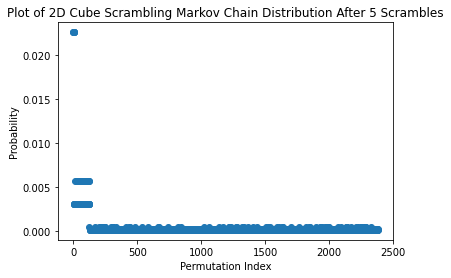

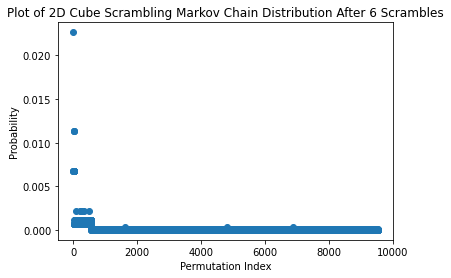

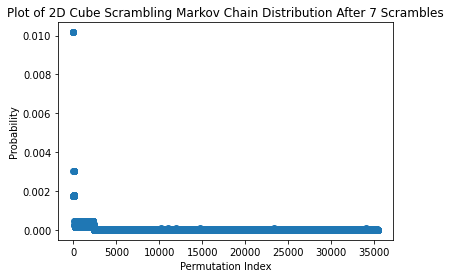

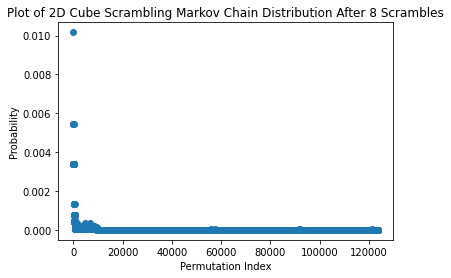

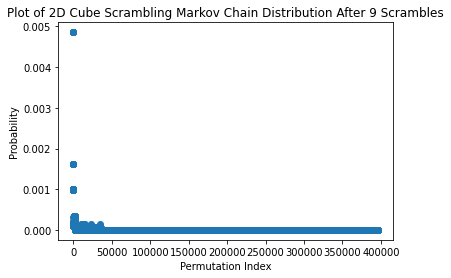

In [6]:
n=2
MC=MarkovChainCalculations(n)
t=29

pis=[]
for j in range(t+1):
    pis.append(MC.compute_chain_distribution(j))

for j in range(10):
    pi=pis[j].data
    fig,ax=plt.subplots()
    ax.scatter(range(len(pi)), pi)
    ax.set_title('Plot of {}D Cube Scrambling Markov Chain Distribution After {} Scrambles'.format(n,j))
    ax.set_xlabel('Permutation Index')
    ax.set_ylabel('Probability')

## Markov Chain Total Variation Distances To Discrete Uniform
Consider the discrete uniform distribution $\pi_\infty$ on $\mathcal{G}_n,$ that is, $\pi_\infty(g)=1/N$ for each $g \in \mathcal{G}_n,$ where $N = \# \ \mathcal{G}_n$ as before. 

For each $t \in \mathbb{N},$ we compute the $\textbf{total variation distance}$ between $\pi_t$ and $\pi_\infty,$ which is the quantity
$$\text{TV}(\pi_t,\pi_\infty) = \frac{1}{2} \|\boldsymbol{\pi}_t - \boldsymbol{\pi}_\infty \|_1,$$ where $\boldsymbol{\pi}_\infty=(1/N, \ \dots \ , 1/N) \in \mathbb{R}^N$ and
$$\| \mathbf{x} \|_1= \sum_{i=0}^{N-1} |x_i|$$ for $\mathbf{x}=(x_0, \ \dots \ , x_{N-1}) \in \mathbb{R}^N.$

We show a plot of the first $30$ total variation distances.

$\textbf{Conjecture}:$ It seems that $$\lim_{t \rightarrow \infty} \text{TV}(\pi_t,\pi_\infty) = 1/2.$$ So the chain distributions do not seem to be approaching the discrete uniform distribution with respect to the total variation distance. In Markov Chain terms, the discrete uniform distribution does NOT seem to be the (correct) stationary distribution of this chain. This suggests once again that in the long run, we cannot obtain all cube configurations with equal probability.

<AxesSubplot:title={'center':'2D Cube Markov Scrambling Chain Total Variation Distances to Discrete Uniform Plot'}, xlabel='Chain Distribution', ylabel='Total Variation Distance to Uniform'>

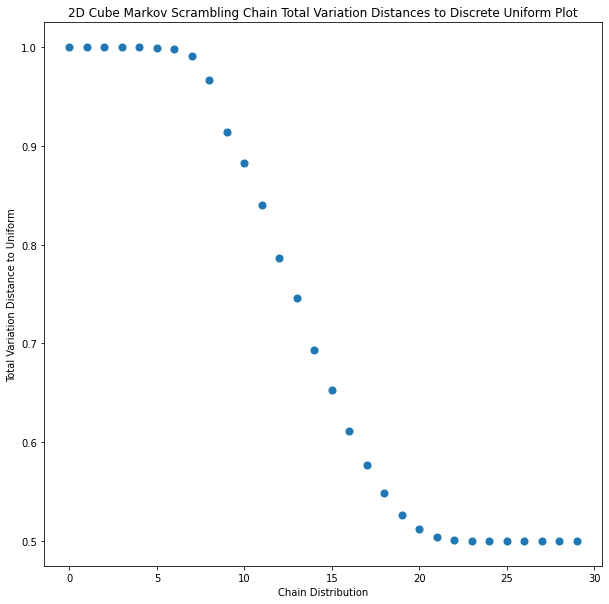

In [7]:
current_total_variation_distances_df=MC.compute_current_total_variation_distances_df()
current_total_variation_distances_df.reset_index(inplace=True)
current_total_variation_distances_df.plot.scatter(x=current_total_variation_distances_df.columns[0],
                                                  y=current_total_variation_distances_df.columns[1],
                                                  figsize=(10,10),
                                                  title='{}D Cube Markov Scrambling Chain Total Variation Distances to Discrete Uniform Plot'.format(n),
                                                  s=50)

# References

* Pocket Cube Devil's Algorithm: http://anttila.ca/michael/devilsalgorithm/.
* Pocket Cube Markov Chain: https://www.lifehacker.com.au/2020/01/how-hard-is-it-to-scramble-rubiks-cube/